<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [2]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 129.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 161.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 149.8 MB/s eta 0:00:00


<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [3]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


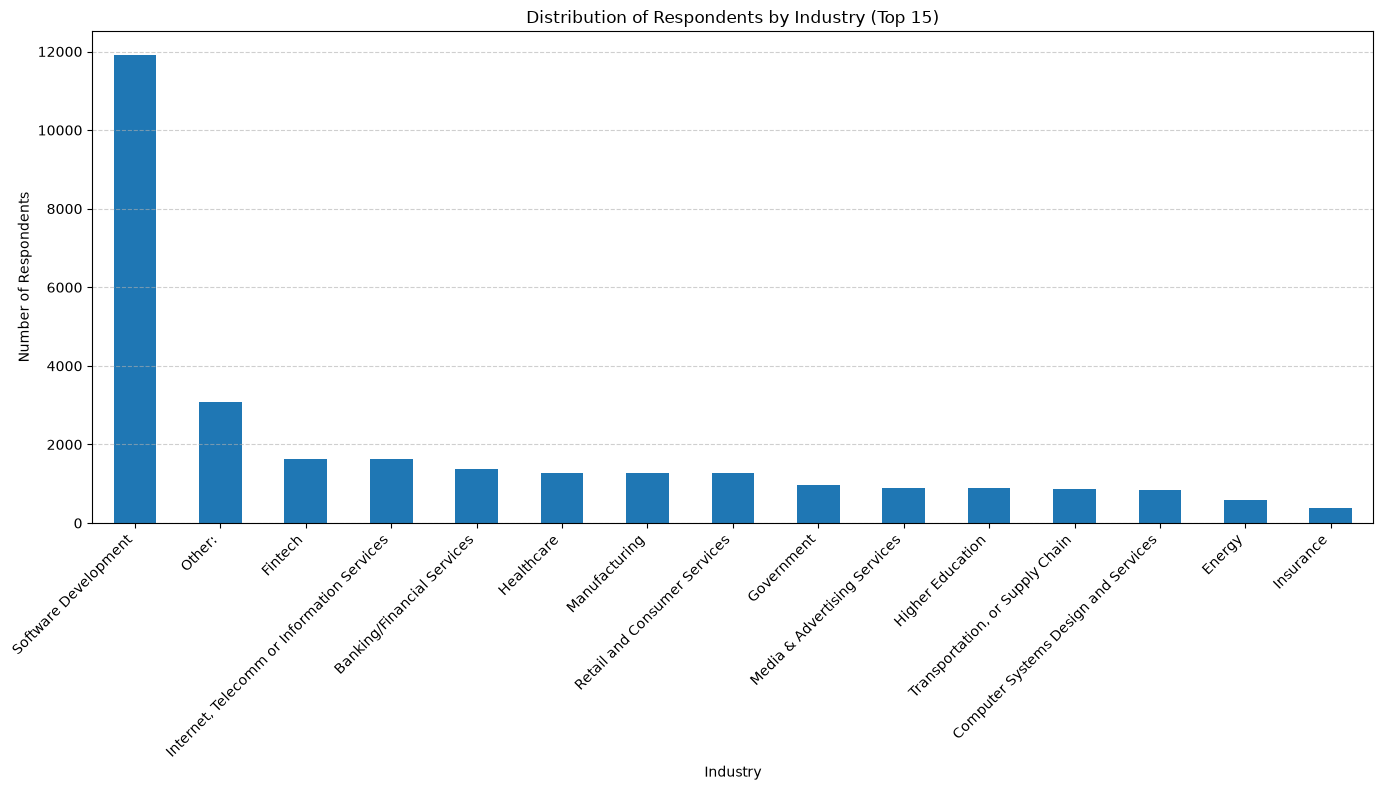

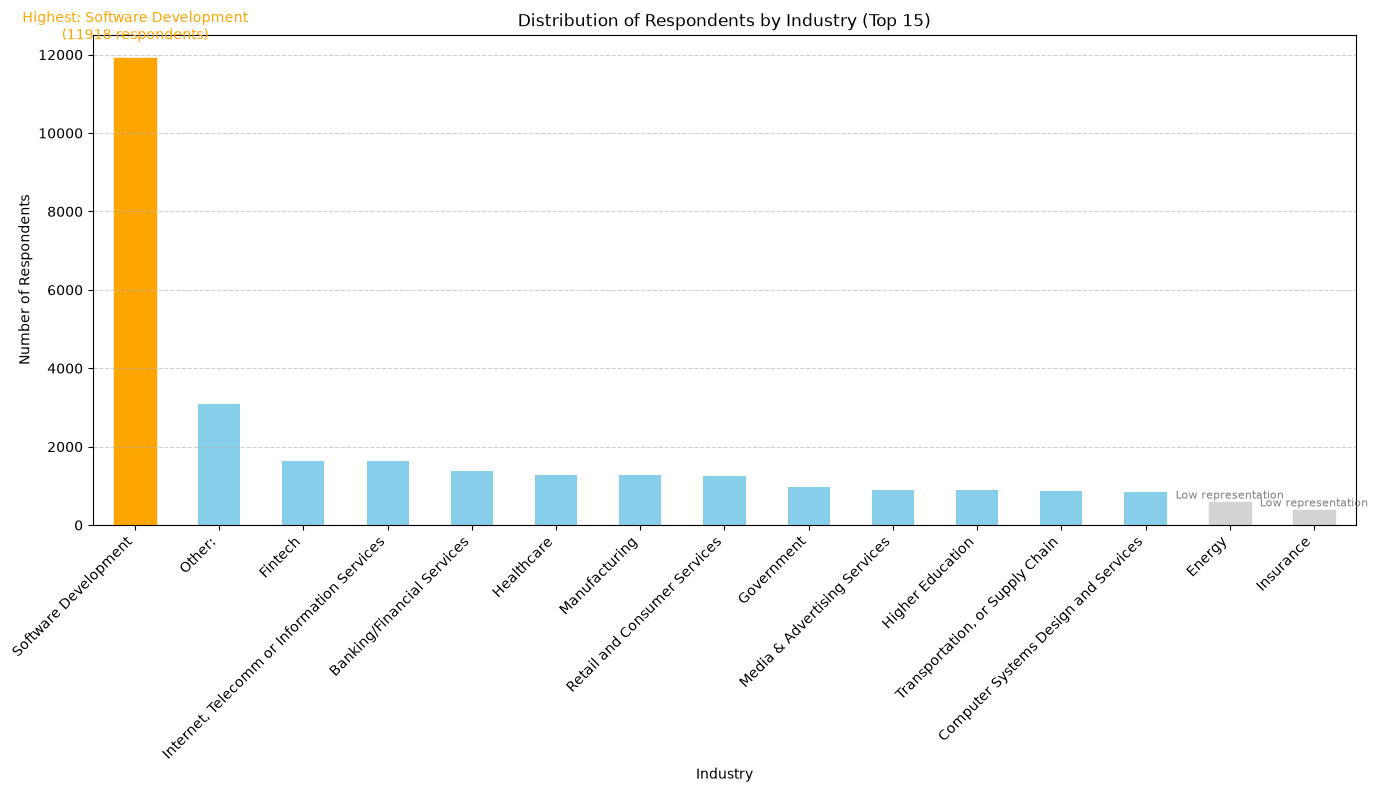

In [7]:
##Write your code here
df['Industry'].unique()[:40]
#count respondents by industry
industry_counts = df['Industry'].value_counts()
industry_counts.head()
import matplotlib.pyplot as plt

# Select top 15 industries
top_industries = industry_counts.head(15)

plt.figure(figsize=(14,8))
top_industries.plot(kind='bar')

plt.title("Distribution of Respondents by Industry (Top 15)")
plt.xlabel("Industry")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


import matplotlib.pyplot as plt

# Count respondents by industry
industry_counts = df['Industry'].value_counts()

# Select top 15 industries for readability
top_industries = industry_counts.head(15)

plt.figure(figsize=(14,8))
bars = top_industries.plot(kind='bar', color='skyblue')

plt.title("Distribution of Respondents by Industry (Top 15)")
plt.xlabel("Industry")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# --- Highlight notable trends directly on the plot ---

# 1. Highlight the top industry in a different color
top_idx = top_industries.idxmax()
top_val = top_industries.max()
bars.patches[0].set_color('orange')  # first bar is the largest due to value_counts ordering

# 2. Annotate the top industry
plt.text(
    0, top_val + (top_val * 0.03),
    f"Highest: {top_idx}\n({top_val} respondents)",
    ha='center', va='bottom', fontsize=10, color='orange'
)

# 3. Highlight industries with noticeably lower representation
low_threshold = top_industries.mean() * 0.4
for i, (ind, val) in enumerate(top_industries.items()):
    if val < low_threshold:
        bars.patches[i].set_color('lightgray')
        plt.text(
            i, val + (val * 0.05),
            "Low representation",
            ha='center', va='bottom', fontsize=8, color='gray'
        )

plt.tight_layout()
plt.show()



<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [8]:
##Write your code here
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
comp = df['ConvertedCompYearly'].dropna()
mean_comp = comp.mean()
median_comp = comp.median()
std_comp = comp.std()

mean_comp, median_comp, std_comp
#Define “extremely high compensation”
#We use the standard statistical rule:
#Values > mean + 3 × std are considered extreme outliers.

threshold = mean_comp + 3 * std_comp
threshold
#identify respondents exceeding the threshold
high_earners = df[df['ConvertedCompYearly'] > threshold]
high_earners[['ConvertedCompYearly']].head()
# Count how many extreme earners exist
high_earners.shape[0]


89

<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


/tmp/ipykernel_302/2765181345.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(comp, vert=False, patch_artist=True,


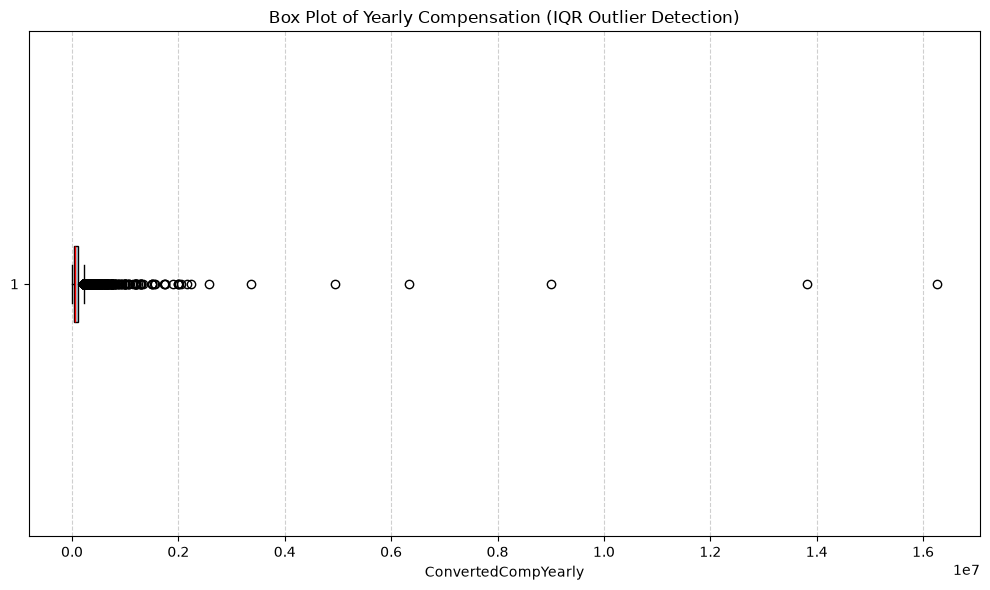

In [13]:
##Write your code here
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
comp = df['ConvertedCompYearly'].dropna()
#Calculate IQR
Q1 = comp.quantile(0.25)
Q3 = comp.quantile(0.75)
IQR = Q3 - Q1

Q1, Q3, IQR
#Determine outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound
#identify outliers
outliers = df[df['ConvertedCompYearly'] > upper_bound]
outliers_count = outliers.shape[0]

outliers_count
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.boxplot(comp, vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='red'))

plt.title("Box Plot of Yearly Compensation (IQR Outlier Detection)")
plt.xlabel("ConvertedCompYearly")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()




<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [14]:
##Write your code here
# Ensure numeric
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')

# Drop NaN for calculation
comp = df['ConvertedCompYearly'].dropna()

# IQR calculation
Q1 = comp.quantile(0.25)
Q3 = comp.quantile(0.75)
IQR = Q3 - Q1

# Outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
#Create a new DataFrame excluding outliers
lower_bound, upper_bound
df_no_outliers = df[(df['ConvertedCompYearly'] >= lower_bound) &
                    (df['ConvertedCompYearly'] <= upper_bound)]
df_no_outliers.shape


(22457, 114)

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


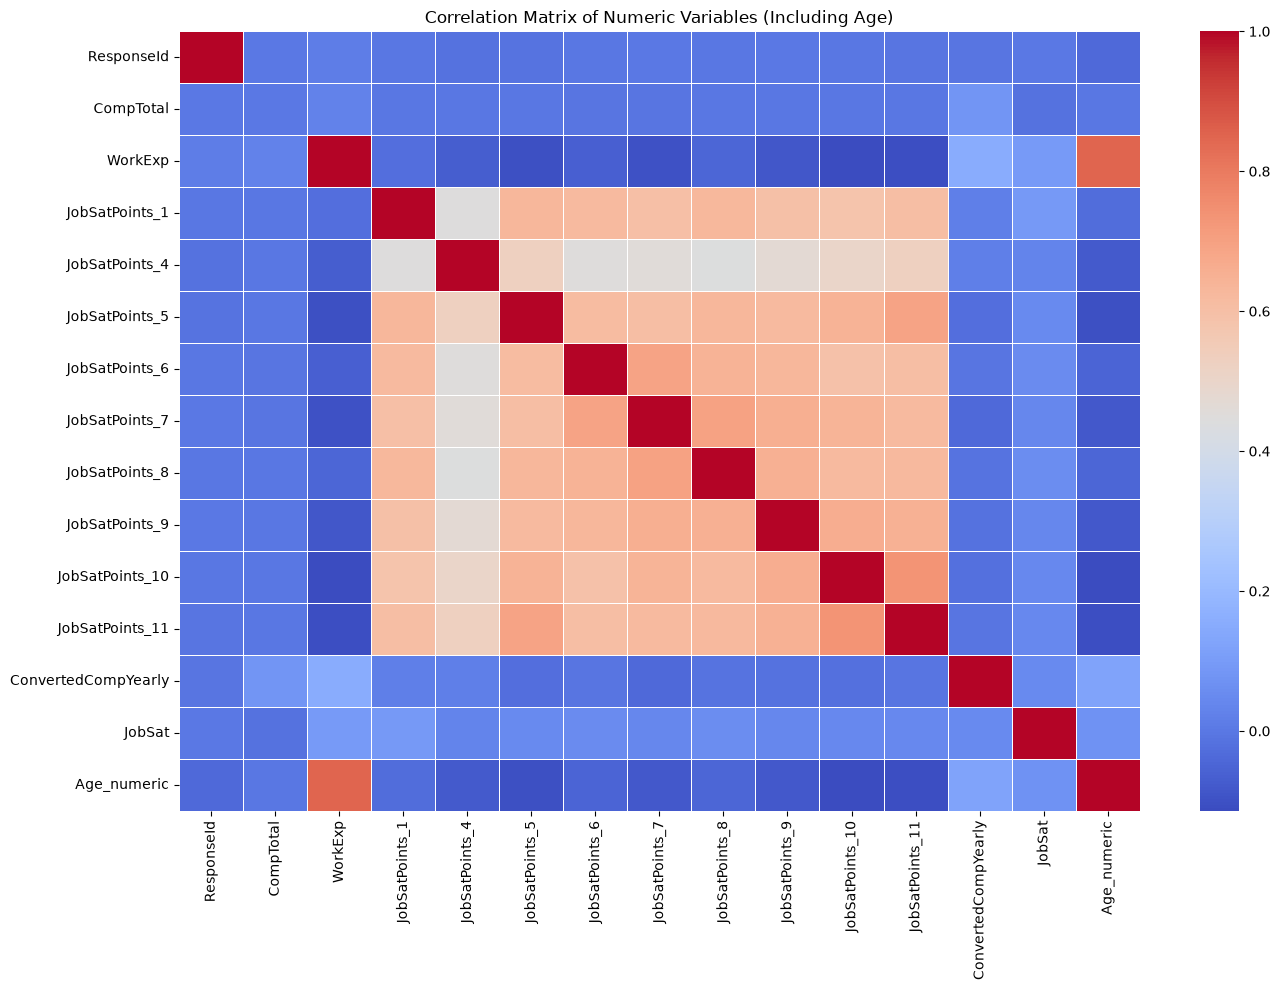

In [17]:
##Write your code here
#Survey datasets often store Age as ranges like:
#“18–24 years”“25–34 years”“35–44 years”“45–54 years”“55–64 years”“65 years or older”
#We convert each range to its midpoint, which is the standard approach for correlation analysis.
def map_age(age):
    if pd.isna(age):
        return None
    age = str(age)

    if "Under 18" in age:
        return 17
    elif "18" in age and "24" in age:
        return 21
    elif "25" in age and "34" in age:
        return 30
    elif "35" in age and "44" in age:
        return 40
    elif "45" in age and "54" in age:
        return 50
    elif "55" in age and "64" in age:
        return 60
    elif "65" in age:
        return 70
    else:
        return None

df['Age_numeric'] = df['Age'].apply(map_age)
#Compute correlations with other numeric variables
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()
corr_matrix['Age_numeric'].sort_values(ascending=False)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Matrix of Numeric Variables (Including Age)")
plt.tight_layout()
plt.show()


<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
